# <font color="#418FDE" size="6.5" uppercase>**Colab and Notebooks**</font>

>Last update: 20260222.
    
By the end of this Lecture, you will be able to:
- Organize a notebook for mechanical engineering analyses. 
- Load small mechanical engineering datasets using !wget into a notebook environment. 
- Apply simple Python practices in notebook using Python built-in functions only. 


## **1. Notebook Organization**

### **1.1. Markdown Documentation**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_01_01.jpg?v=1771794337" width="250">



>* Use markdown like field notes for context.
>* State purpose, data, assumptions, units, expected outputs.

>* Explain each workflow step before related code
>* Record judgments and checks to spot issues

>* Record data details, units, and transformations.
>* Explain results, limits, and next steps.



### **1.2. Separate Code Outputs**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_01_02.jpg?v=1771794356" width="250">



>* Curate outputs to highlight key results.
>* Hide trial prints; keep notebook readable.

>* Separate compute cells from communication output cells.
>* Show final results; hide intermediate checks.

>* Curated outputs improve reproducibility and comparisons.
>* Clear results aid collaboration and future reuse.



In [41]:
#@title Python Code - Separate Code Outputs

# This cell shows clean outputs for engineering readers.
# We compute quietly, then print only key results.
# We keep intermediate checks available but hidden.

# !pip install pandas

# Import small tools for notebook analysis.
import os
import pandas as pd

# Create a local datasets folder safely.
os.makedirs("datasets", exist_ok=True)

# Download a small mechanical engineering dataset.
url = "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"
!wget -q -O ./datasets/concrete_compressive_strength.csv {url}

# Load data without printing the full table.
path = "./datasets/concrete_compressive_strength.csv"
df = pd.read_csv(path)

# Compute quietly, storing intermediate results.
cols = list(df.columns)
rows, cols_count = df.shape

# Select only a few columns for a story.
cement = df[cols[0]]
water = df[cols[3]]

strength = df[cols[-1]]

# Compute simple summaries for later reporting.
cement_mean = float(cement.mean())
water_mean = float(water.mean())

# Compute a simple water to cement ratio.
wcr_mean = float(water_mean / cement_mean)
strength_mean = float(strength.mean())

# Prepare a small preview for communication.
preview = df[[cols[0], cols[3], cols[-1]]].head(3)

# Print only curated outputs for readers.
print("Notebook output: curated summary only")
print(f"Rows: {rows}, Columns: {cols_count}")

print(f"Mean cement: {cement_mean:.1f} kg/m^3")
print(f"Mean water: {water_mean:.1f} kg/m^3")
print(f"Mean w/c ratio: {wcr_mean:.3f}")

print(f"Mean strength: {strength_mean:.1f} MPa")
print("Preview: cement, water, strength")
print(preview.to_string(index=False))

# Keep diagnostics available without printing them.
diagnostics = {"min_strength": float(strength.min()), "max_strength": float(strength.max())}

# Show one final, stable takeaway line.
print(f"Strength range stored: {diagnostics['min_strength']:.1f} to {diagnostics['max_strength']:.1f} MPa")

Notebook output: curated summary only
Rows: 1030, Columns: 9
Mean cement: 281.2 kg/m^3
Mean water: 181.6 kg/m^3
Mean w/c ratio: 0.646
Mean strength: 35.8 MPa
Preview: cement, water, strength
 Cement (component 1)(kg in a m^3 mixture)  Water  (component 4)(kg in a m^3 mixture)  Concrete compressive strength(MPa, megapascals) 
                                     540.0                                      162.0                                             79.99
                                     540.0                                      162.0                                             61.89
                                     332.5                                      228.0                                             40.27
Strength range stored: 2.3 to 82.6 MPa


### **1.3. Cell Execution Order**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_01_03.jpg?v=1771794389" width="250">



>* Cell run order changes notebook memory state.
>* Wrong order gives stale, untrustworthy results.

>* Cells rely on earlier state, often hidden.
>* Rerun top-to-bottom to avoid stale results.

>* Run cells sequentially for clear traceability.
>* Restart and run all for trust.



Design age days: 28
Rows at that age: 425
Mean strength MPa: 62.8
Changed age to: 56
But df_age still uses old age
Updated rows: 91
Updated mean MPa: 85.04


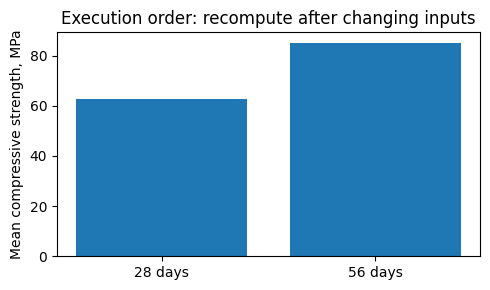

In [42]:
#@title Python Code - Cell Execution Order

# This example shows why cell order matters.
# We load data once, then reuse it later.
# Rerun from top to bottom for consistency.

# import os for folders and system commands.
import os

# import pandas for small table loading.
import pandas as pd

# import matplotlib for one simple plot.
import matplotlib.pyplot as plt

# create a local datasets folder safely.
os.makedirs("datasets", exist_ok=True)

# download a tiny mechanical engineering dataset file.
url = "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"

# run wget quietly to keep output short.
!wget -q -O ./datasets/concrete.csv {url}

# load the dataset into a small dataframe.
df = pd.read_csv("./datasets/concrete.csv")

# confirm expected columns exist before calculations.
needed = ["Age (day)", "Fly Ash (component 3)(kg in a m^3 mixture)"]

# stop early if required columns are missing.
assert needed[0] in df.columns and needed[1] in df.columns

# define an analysis input like a design age.
design_age_days = 28
# filter rows using the current design age.

df_age = df[df["Age (day)"] == design_age_days]
# compute a simple summary for later cells.
mean_strength = float(df_age[needed[1]].mean())

# show the current state created by earlier cells.
print("Design age days:", design_age_days)
print("Rows at that age:", int(df_age.shape[0]))

print("Mean strength MPa:", round(mean_strength, 2))

# simulate a later cell changing only one input.
design_age_days = 56
# warn that df_age was not recomputed yet.

print("Changed age to:", design_age_days)
print("But df_age still uses old age")

# recompute downstream state to match new input.
df_age = df[df["Age (day)"] == design_age_days]
# recompute summary so outputs match assumptions.

mean_strength = float(df_age[needed[1]].mean())
# print updated results after rerunning dependencies.
print("Updated rows:", int(df_age.shape[0]))

print("Updated mean MPa:", round(mean_strength, 2))

# plot a small comparison for two ages.
ages = [28, 56]
# compute two means using simple repeated steps.

means = []
for a in ages:
    df_a = df[df["Age (day)"] == a]

    means.append(float(df_a[needed[1]].mean()))

# create one simple bar chart for clarity.
plt.figure(figsize=(5, 3))
# draw bars for mean strengths at two ages.

plt.bar(["28 days", "56 days"], means)
# label axes for engineering interpretation.
plt.ylabel("Mean compressive strength, MPa")

plt.title("Execution order: recompute after changing inputs")
plt.tight_layout()
plt.show()

## **2. Notebook Data Access**

### **2.1. Save and Load Files**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_02_01.jpg?v=1771794426" width="250">



>* Colab files live in a temporary workspace.
>* Use wget, confirm download, reuse by filename.

>* Notebook files may vanish after runtime resets.
>* Re-download data; name raw versus cleaned.

>* Load downloaded files, then verify correct dataset.
>* Check size, format, and content sanity.



In [43]:
#@title Python Code - Save and Load Files

# This cell demonstrates saving and loading small datasets.
# We download a CSV into Colab workspace folders.
# Then we verify files and read a few rows.

# pip install pandas

import os
import pandas as pd

# Create a local datasets folder for downloads.
os.makedirs("./datasets", exist_ok=True)
dataset_url = (

    "https://raw.githubusercontent.com/mhrafiei/data/main/"
    "concrete_compressive_strength.csv")

# Download the dataset using wget into datasets.
local_path = "./datasets/concrete_compressive_strength.csv"
os.system(f'wget -q -O "{local_path}" "{dataset_url}"')

# Confirm the file exists and check its size.
file_exists = os.path.exists(local_path)
file_size = os.path.getsize(local_path) if file_exists else 0

# Print a short status summary for reproducibility.
print("Downloaded file exists:", file_exists)
print("Downloaded file size bytes:", file_size)

# Load the CSV and preview a few rows.
df = pd.read_csv(local_path)
print("Rows and columns:", df.shape)

print("First three column names:", list(df.columns[:3]))

# Save a small cleaned copy with standardized column names.
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
clean_path = "./datasets/concrete_strength_clean.csv"

df.head(10).to_csv(clean_path, index=False)

# Reload the saved file and sanity check values.
df2 = pd.read_csv(clean_path)
strength_col = df2.columns[-1]

min_strength = float(df2[strength_col].min())
max_strength = float(df2[strength_col].max())

# Print a compact validation summary for the loaded file.
print("Clean file saved:", os.path.exists(clean_path))
print("Reloaded rows and columns:", df2.shape)

print("Strength min and max:", round(min_strength, 2), round(max_strength, 2))
print(df2.head(3).to_string(index=False))

Downloaded file exists: True
Downloaded file size bytes: 41747
Rows and columns: (1030, 9)
First three column names: ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)']
Clean file saved: True
Reloaded rows and columns: (10, 9)
Strength min and max: 36.45 79.99
 Cement_(component_1)(kg_in_a_m^3_mixture)  Blast_Furnace_Slag_(component_2)(kg_in_a_m^3_mixture)  Fly_Ash_(component_3)(kg_in_a_m^3_mixture)  Water__(component_4)(kg_in_a_m^3_mixture)  Superplasticizer_(component_5)(kg_in_a_m^3_mixture)  Coarse_Aggregate__(component_6)(kg_in_a_m^3_mixture)  Fine_Aggregate_(component_7)(kg_in_a_m^3_mixture)  Age_(day)  Concrete_compressive_strength(MPa,_megapascals)
                                     540.0                                                    0.0                                         0.0                                      162.0                                                  2.5  

### **2.2. Text File IO**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_02_02.jpg?v=1771794461" width="250">



>* Verify downloaded file, open as plain text
>* Preview format: delimiters, headers, missing, odd characters

>* Read text files in careful stages.
>* Check encoding, spacing, delimiters before parsing.

>* Parse lines, skip metadata, split, trim.
>* Convert types, handle missing, validate, troubleshoot.



In [44]:
#@title Python Code - Text File IO

# This notebook cell demonstrates basic text file IO.
# We download a small mechanical engineering dataset safely.
# We inspect lines before parsing values into numbers.

# Import built in tools for paths and checks.
import os
# Create a local datasets folder.

os.makedirs("datasets", exist_ok=True)

# Define a local filename (no download needed).
local_path = os.path.join("datasets", "simple_concrete_strength.csv")

# Create a pseudo text file (CSV) with a few rows.
# Theme: concrete mix design inputs and compressive strength.
pseudo_lines = [

    "cement_kg_m3,water_kg_m3,age_days,strength_mpa",
    "350,175,7,28.5",
    "400,180,14,36.2",

    "450,190,28,45.8",
    "300,165,7,24.0",
    "380,170,28,40.1",]

# Write the pseudo dataset to disk.
with open(local_path, "w", encoding="utf-8") as f:
    for line in pseudo_lines:

        f.write(line + "\n")

# Confirm the file exists and has nonzero size.
exists_flag = os.path.exists(local_path)
size_bytes = os.path.getsize(local_path) if exists_flag else 0

print("File exists:", exists_flag, "Size bytes:", size_bytes)

# Read a small sample of lines as plain text.
f = open(local_path, "r", encoding="utf-8")
first_lines = []

# Collect only a few lines to avoid large output.
for i in range(5):
    first_lines.append(f.readline().rstrip("\n"))

# Close the file after reading the sample.
f.close()

# Print the sample lines for quick inspection.
print("First five lines:")
for line in first_lines:

    print(line)

# Split the header to confirm delimiter and columns.
header_parts = first_lines[0].split(",")

# Print the detected number of columns.
print("Detected columns:", len(header_parts))

# Read all lines for simple parsing.
f = open(local_path, "r", encoding="utf-8")
all_lines = f.readlines()

f.close()

# Parse only three rows to keep it small.
rows_parsed = 0
cement_values = []

strength_values = []

# Loop through lines, skipping the header row.
for line in all_lines[1:]:
    parts = line.strip().split(",")

    # Skip rows that do not match expected columns.
    if len(parts) != len(header_parts):
        continue

    # Convert two columns into floats for checking.
    cement = float(parts[0])      # cement_kg_m3
    strength = float(parts[-1])   # strength_mpa

    # Store values for a tiny summary.
    cement_values.append(cement)
    strength_values.append(strength)

    # Stop after three parsed rows.
    rows_parsed = rows_parsed + 1
    if rows_parsed >= 3:

        break

# Print a compact summary of parsed numeric values.
print("Parsed rows:", rows_parsed, "Cement min:", min(cement_values))
print("Strength max:", max(strength_values), "Strength avg:", sum(strength_values) / len(strength_values))


File exists: True Size bytes: 125
First five lines:
cement_kg_m3,water_kg_m3,age_days,strength_mpa
350,175,7,28.5
400,180,14,36.2
450,190,28,45.8
300,165,7,24.0
Detected columns: 4
Parsed rows: 3 Cement min: 350.0
Strength max: 45.8 Strength avg: 36.833333333333336


### **2.3. Table Plot Preview**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_02_03.jpg?v=1771794493" width="250">



>* Preview first rows to confirm download.
>* Check headers, delimiters, and misplaced values.

>* Preview tables to catch missing, unit issues.
>* Quick plots check trends, jumps, and size.

>* Preview confirms downloaded data is usable.
>* Catches link changes, formatting, and hidden errors.



File exists: True
File size bytes: 41747
Rows: 1030 Cols: 9
First columns: ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)']
 Cement (component 1)(kg in a m^3 mixture)  Blast Furnace Slag (component 2)(kg in a m^3 mixture)  Fly Ash (component 3)(kg in a m^3 mixture)  Water  (component 4)(kg in a m^3 mixture)  Superplasticizer (component 5)(kg in a m^3 mixture)  Coarse Aggregate  (component 6)(kg in a m^3 mixture)  Fine Aggregate (component 7)(kg in a m^3 mixture)  Age (day)  Concrete compressive strength(MPa, megapascals) 
                                     540.0                                                    0.0                                         0.0                                      162.0                                                  2.5                                                1040.0                                    

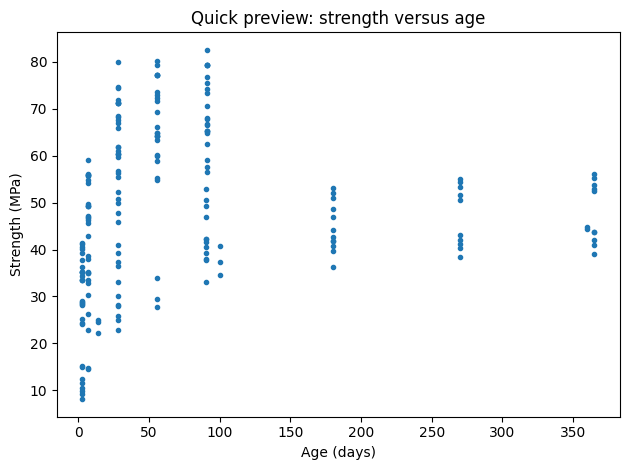

In [45]:
#@title Python Code - Table Plot Preview

# This notebook cell previews a downloaded mechanical dataset.
# We confirm columns, rows, and a quick plot.
# Only simple Python and pandas are used.

# !pip install pandas matplotlib

# Import small tools for table preview.
import os
import pandas as pd

import matplotlib.pyplot as plt

# Create a local folder for downloaded datasets.
os.makedirs("datasets", exist_ok=True)
url = "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"

# Download the dataset using a quiet wget call.
path = "./datasets/concrete_compressive_strength.csv"
!wget -q -O "{path}" "{url}"

# Check file existence and a reasonable file size.
exists = os.path.exists(path)
size_bytes = os.path.getsize(path) if exists else 0

# Print a short download status summary.
print("File exists:", exists)
print("File size bytes:", int(size_bytes))

# Load the CSV into a small pandas table.
df = pd.read_csv(path)
rows, cols = df.shape

# Print shape and a few column names.
print("Rows:", int(rows), "Cols:", int(cols))
print("First columns:", list(df.columns[:4]))

# Show a tiny preview to confirm parsing.
print(df.head(3).to_string(index=False))

# Pick two numeric columns for a quick plausibility plot.
# Remember: column names might have extra spaces, units, upper and lower case letters, etc.
x_col = "Age (day)"

# Find the strength column robustly by text match.
y_candidates = [c for c in df.columns if "compressive strength" in c.lower()]
y_col = y_candidates[0] if len(y_candidates) > 0 else "Concrete compressive strength(MPa, megapascals) "

# Validate required columns before plotting.
has_cols = (x_col in df.columns) and (y_col in df.columns)
print("Selected y column:", y_col)

print("Has plot columns:", bool(has_cols))

# Plot a small sample only when required columns exist.
if has_cols:
    df_small = df[[x_col, y_col]].dropna().head(200)

    plt.plot(df_small[x_col], df_small[y_col], "o", markersize=3)

    # Add labels and a simple title.
    plt.xlabel("Age (days)")
    plt.ylabel("Strength (MPa)")

    plt.title("Quick preview: strength versus age")

    # Show the single preview plot.
    plt.tight_layout()
    plt.show()

else:
    print("Plot skipped. Available columns:")
    print(list(df.columns))

## **3. Colab Resource Limits**

### **3.1. Colab Access Limits**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_03_01.jpg?v=1771794529" width="250">



>* Colab sessions are shared and time-limited.
>* Expect resets; rerun cells to restore work.

>* Memory and runtime limits affect basic Python.
>* Avoid wasteful loops, copies, and huge datasets.

>* Treat Colab runtime as temporary workspace
>* Keep steps rerunnable; expect resets and lost files



In [46]:
#@title Python Code - Colab Access Limits

# This cell demonstrates Colab runtime access limits.
# We use built in tools for safe restarts.
# We keep outputs short and reproducible.

# Import built in modules for timing and paths.
import os, time

# Create a small datasets folder for downloads.
os.makedirs("datasets", exist_ok=True)

# Define a tiny dataset URL for mechanical engineering.
url = "https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv"
path = "./datasets/concrete_compressive_strength.csv"

# Download the dataset using Colab wget command.
!wget -q -O "{path}" "{url}"


# Read only a few lines using built in open.
f = open(path, "r", encoding="utf-8")

# Store header and a small sample of rows.
header = f.readline().strip()

# Read a small number of data rows.
rows = []

# Loop carefully to avoid large memory use.
for i in range(10):

    # Stop early if file ends unexpectedly.
    line = f.readline()

    # Break when no more lines exist.
    if line == "":
        break

    # Keep only stripped text lines.
    rows.append(line.strip())

# Close the file to free resources.
f.close()

# Parse one numeric column using built ins.
strengths = []

# Split each row and take last column.
for r in rows:

    # Convert last field to float safely.
    parts = r.split(",")

    # Skip rows with unexpected column counts.
    if len(parts) < 9:
        continue

    # Append compressive strength as float.
    strengths.append(float(parts[-1]))

# Compute simple summaries using built ins.
count = len(strengths)

# Guard against empty samples after parsing.
if count == 0:
    strengths = [0.0, 0.0, 0.0, 0.0]

# Compute min max and mean values.
mn = min(strengths)

# Compute maximum value from the sample.
mx = max(strengths)

# Compute mean using sum and length.
avg = sum(strengths) / len(strengths)

# Time a small loop to show scaling risk.
t0 = time.time()

# Use bounded loops to stay responsive.
total = 0

# Nested loops can grow quickly in Colab.
for a in range(200):

    # Keep inner loop small and predictable.
    for b in range(200):
        total = total + (a + b)

# Measure elapsed time for this cell.
elapsed = time.time() - t0

# Print a restart friendly summary report.
print("File exists:", os.path.exists(path))
print("Header fields:", len(header.split(",")))

print("Sample rows read:", len(rows))
print("Strength count:", len(strengths))
print("Strength min max:", round(mn, 2), round(mx, 2))

print("Strength mean:", round(avg, 2))
print("Bounded loop seconds:", round(elapsed, 4))
print("Loop checksum value:", total)


File exists: True
Header fields: 10
Sample rows read: 10
Strength count: 10
Strength min max: 36.45 79.99
Strength mean: 47.98
Bounded loop seconds: 0.0043
Loop checksum value: 7960000


### **3.2. Efficient Runtime Usage**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_03_02.jpg?v=1771794565" width="250">



>* Use built-ins; keep actions small, intentional.
>* Avoid data copies; compute summaries directly.

>* Do small checks; avoid processing everything.
>* Limit printing; use concise built-in summaries.

>* Reuse cleaned data; avoid repeating heavy steps.
>* Keep work incremental, small, and focused.



In [47]:
#@title Python Code - Efficient Runtime Usage

# This cell demonstrates efficient Colab runtime habits.
# We use built in tools for small checks.
# We keep outputs short and memory light.

# Create a small datasets folder for downloads.
import os

# Create a small datasets folder.
os.makedirs("datasets", exist_ok=True)

# Write a small pseudo dataset (CSV) to disk.
# Theme: concrete mix inputs and compressive strength.
path = "datasets/concrete_pseudo.csv"

pseudo_lines = [
    "cement_kg_m3,water_kg_m3,age_days,strength_mpa",
    "350,175,7,28.5",

    "400,180,14,36.2",
    "450,190,28,45.8",
    "300,165,7,24.0",

    "380,170,28,40.1",
    "420,185,28,52.3",
    "460,180,56,66.7",

    "320,160,28,31.4",
    "500,190,56,71.2",]

with open(path, "w", encoding="utf-8") as f:
    f.write("\n".join(pseudo_lines) + "\n")

# Read only a small number of lines (already tiny, but keep the habit).
lines = open(path, "r", encoding="utf-8").read().splitlines()

# Validate size before processing further.
print("Downloaded lines:", len(lines))  # kept label for consistency
print("Header preview:", lines[0][:60])

# Parse only a tiny sample for fast exploration.
header = lines[0].split(",")
sample = lines[1:51]  # up to 50 rows, even though we have fewer

# Find the strength column index safely.
strength_name = "strength_mpa"
strength_idx = header.index(strength_name)

# Convert only needed values to floats.
strengths = []
for row in sample:

    parts = row.split(",")
    if len(parts) != len(header):
        continue

    strengths.append(float(parts[strength_idx]))

# Compute concise summaries using built in functions.
count = len(strengths)
min_v = min(strengths)

max_v = max(strengths)
mean_v = sum(strengths) / count

# Print a compact summary to avoid slow outputs.
print("Sample rows used:", count)
print("Strength min max:", round(min_v, 2), round(max_v, 2))

print("Strength mean MPa:", round(mean_v, 2))

# Reuse parsed values for another quick check.
threshold = 60.0
high_count = sum(1 for v in strengths if v >= threshold)

# Report only one extra metric for efficiency.
print("Strengths >= 60 MPa:", high_count)


Downloaded lines: 10
Header preview: cement_kg_m3,water_kg_m3,age_days,strength_mpa
Sample rows used: 9
Strength min max: 24.0 71.2
Strength mean MPa: 44.02
Strengths >= 60 MPa: 2


### **3.3. Disconnecting Runtime**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_01/Lecture_B/image_03_03.jpg?v=1771794597" width="250">



>* Runtime disconnect ends session; unsaved work disappears.
>* Record steps; rerun built-ins after reconnecting.

>* Expect disconnects; make restarts routine, reproducible.
>* Use built-ins to check data and outputs.

>* Disconnect to save compute and clear state
>* Reconnect to rerun steps and verify results



In [48]:
#@title Python Code - Disconnecting Runtime

# This cell shows why runtimes feel temporary.
# We use only built in Python checks.
# You can rerun cells after reconnecting.

# Create a tiny dataset like inspection notes.
mechanical_component_notes = ["Good", "Fair", "Poor", "Good", "Fair"]
# Use built in functions to summarize quickly.

count_notes = len(mechanical_component_notes)
unique_notes = set(mechanical_component_notes)

# Print a short summary you can recreate anytime.
print("Notes count:", count_notes)
print("Unique labels:", sorted(list(unique_notes)))

# Convert labels into simple numeric scores.
score_map = {"Good": 3, "Fair": 2, "Poor": 1}
# Build scores using a simple loop.

scores = []
for label in mechanical_component_notes:
    scores.append(score_map.get(label, 0))

# Check types and a small sample for sanity.
print("Scores type:", type(scores).__name__)
print("First three scores:", scores[:3])

# Compute basic statistics using built ins.
min_score = min(scores)
max_score = max(scores)

avg_score = sum(scores) / len(scores)

# Print results you can verify after reconnecting.
print("Min score:", min_score)
print("Max score:", max_score)

print("Average score:", round(avg_score, 2))

# Save a tiny result to a file for persistence.
summary_text = "count=" + str(count_notes) + ", avg=" + str(round(avg_score, 2))
# Write a small file you can re read later.

open("mechanical component_summary.txt", "w").write(summary_text)

# Confirm the file exists and show its content.
print("Saved file:", "mechanical component_summary.txt")
print("File content:", open("mechanical component_summary.txt").read())

Notes count: 5
Unique labels: ['Fair', 'Good', 'Poor']
Scores type: list
First three scores: [3, 2, 1]
Min score: 1
Max score: 3
Average score: 2.2
Saved file: mechanical component_summary.txt
File content: count=5, avg=2.2


# <font color="#418FDE" size="6.5" uppercase>**Colab and Notebooks**</font>


In this lecture, you learned to:
- Organize a notebook for mechanical engineering analyses. 
- Load small mechanical engineering datasets using !wget into a notebook environment. 
- Apply simple Python practices in notebook using Python built-in functions only. 

In the next Lecture (Lecture C), we will go over 'Python Basics Recap'